# Privacy-Preserving Machine Learning: Static Matrix Masking & Domain Generalization

## 1. Specification of Dependencies & Data Setup
Following NeurIPS guidelines for research code reproducibility, this section explicitly defines the environment, dependencies, and datasets required to run this framework.

**Dependencies:**
* `medmnist`, `scikit-learn`, `matplotlib`, `seaborn`, `torchvision`, `torch`
* These can be installed via the inline pip command below. Python 3.x and a CUDA-enabled GPU are highly recommended.

**Dataset (OrganAMNIST):**
* We use the OrganAMNIST dataset. The code below will automatically download the required splits directly using the official `medmnist` library, requiring no manual downloading or directory setup from the user.

**The Static Constraint & Framework Overview:**
To minimize computational overhead, the data owner (the hospital) generates exactly **one static mask per class batch** before training ($L = AX$). This encrypted dataset is sent to the cloud, and the cloud model trains exclusively on this statically masked data.

In [1]:
# --- Installation ---
!pip install -q medmnist scikit-learn matplotlib seaborn torchvision

# --- Imports ---
import time
import copy
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import transforms
from sklearn.metrics import accuracy_score
import medmnist

# --- Setup Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# --- Core Row Mask Generator (GPU Optimized) ---
def generate_row_mask_gpu(y_batch, n, device, seed=None):
    if seed is not None: torch.manual_seed(seed)
    u = torch.ones(n, 1, device=device) / (n ** 0.5)
    y = y_batch.view(n, 1).float()
    proj = (y.t() @ u) * u
    y_ortho = y - proj
    norm_y = torch.norm(y_ortho)

    if norm_y < 1e-6:
        fixed_basis = u
        k = 1
    else:
        y_ortho = y_ortho / norm_y
        fixed_basis = torch.cat([u, y_ortho], dim=1)
        k = 2

    M = torch.randn(n, n, device=device)
    M[:, :k] = fixed_basis
    Q, _ = torch.linalg.qr(M)

    n_noise = n - k
    rand_noise = torch.randn(n_noise, n_noise, device=device)
    W, _ = torch.linalg.qr(rand_noise)

    Q_fixed = fixed_basis
    Q_noise = Q[:, k:]

    return (Q_fixed @ Q_fixed.t()) + (Q_noise @ W @ Q_noise.t())

# --- Load Raw Data ---
DATA_FLAG = 'organamnist'
info = medmnist.INFO[DATA_FLAG]
DataClass = getattr(medmnist, info['python_class'])

transform_vector = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5]),
    transforms.Lambda(lambda x: x.view(-1))
])

print("Downloading and processing OrganAMNIST...")
train_dataset_full = DataClass(split='train', transform=transform_vector, download=True, size=64)
test_dataset_full = DataClass(split='test', transform=transform_vector, download=True, size=64)

train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size
train_subset, val_subset = random_split(train_dataset_full, [train_size, val_size])

IMAGE_DIM = 64 * 64
BATCH_SIZE = 2000
num_classes = len(info['label'])

# --- Generate Static Masked Dataset (Hospital -> Cloud) ---
def create_static_masked_dataset(original_subset, batch_size, device):
    loader = DataLoader(original_subset, batch_size=len(original_subset), shuffle=False)
    X_all, Y_all = next(iter(loader))
    X_all, Y_all = X_all.to(device), Y_all.to(device)
    if Y_all.dim() > 1: Y_all = Y_all.squeeze()

    X_masked_list, Y_list = [], []
    unique_classes = torch.unique(Y_all)

    for cls in unique_classes:
        indices = (Y_all == cls).nonzero(as_tuple=True)[0]
        X_sub, Y_sub = X_all[indices], Y_all[indices]
        n_c = len(indices)

        if n_c > 1:
            A_class = generate_row_mask_gpu(Y_sub, n_c, device)
            X_sub_masked = torch.matmul(A_class, X_sub)
        else:
            X_sub_masked = X_sub

        X_masked_list.append(X_sub_masked)
        Y_list.append(Y_sub)

    return TensorDataset(torch.cat(X_masked_list, dim=0), torch.cat(Y_list, dim=0))

print(f"Simulating Hospital Workflow: Encrypting Data into Static Batches of {BATCH_SIZE}...")
train_masked_ds = create_static_masked_dataset(train_subset, BATCH_SIZE, device)
test_masked_ds = create_static_masked_dataset(test_dataset_full, BATCH_SIZE, device)

def evaluate_model(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_b, Y_b in loader:
            preds.append(torch.argmax(model(X_b.to(device)), dim=1).cpu().numpy())
            labels.append(Y_b.squeeze().cpu().numpy())
    return accuracy_score(np.concatenate(labels), np.concatenate(preds))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.3 MB/s eta 0:00:00
Using device: cuda


100%|██████████| 200M/200M [00:26<00:00, 7.66MB/s]


Simulating Hospital Workflow: Encrypting Data into Static Batches of 2000...


## 2. Model Architecture Definitions
To ensure complete transparency and allow other researchers to build upon our work, we define the exact `RobustCNN` architecture used in our experiments below.

**Hyperparameters & Structure:**
We utilize a Convolutional Neural Network equipped with an `Input Dropout` layer. As analyzed in the paper, $p=0.1$ is the optimal dropout rate to prevent the CNN from overfitting to the Gaussian noise generated by the mask, forcing it to learn macroscopic geometric features. This class is written with extensibility in mind so users can apply it to their own datasets.

In [2]:
class RobustCNN(nn.Module):
    def __init__(self, num_classes=11, dropout_p=0.1):
        super(RobustCNN, self).__init__()
        # Optimal Input Dropout from Phase 3 results
        self.input_drop = nn.Dropout2d(p=dropout_p)
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 7, padding=3), nn.BatchNorm2d(32), nn.ReLU(), nn.AvgPool2d(2),
            nn.Conv2d(32, 64, 5, padding=2), nn.BatchNorm2d(64), nn.ReLU(), nn.AvgPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AvgPool2d(2),
            nn.Flatten()
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 8 * 8, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = x.view(-1, 1, 64, 64)
        x = self.input_drop(x)
        return self.classifier(self.features(x))

## 3. Training & Evaluation Code: Cloud Training & Local Fine-Tuning
This section provides the exact training script used to obtain the principal performance and overhead results stated in the paper.

**Training Procedure & Hyperparameters:**
* **Cloud Phase:** Heavy training on masked data using the Adam optimizer (`lr=0.001`), `CrossEntropyLoss`, and a batch size of 2000. We train for up to 50 epochs with an early stopping patience of 5 to prevent overfitting.
* **Hospital Phase (Domain Adaptation):** Minimal transfer learning on raw data using AdamW (`lr=1e-4`, `weight_decay=1e-3`) for better generalization. Locked to a maximum of 5 epochs (patience=1) to ensure hospital computational burden remains negligible.

**Reproducing Overhead Metrics:**
This cell evaluates the model and computes the precise time and GPU memory consumed during both phases. Running this will directly reproduce the overhead calculation tables discussed in our results.

In [3]:
print("\n=====================================================================")
print("CLOUD TRAINING & HOSPITAL LOCAL FINE-TUNING (OVERHEAD CALCULATION)")
print("=====================================================================")

# Initialize fresh model and loaders
cloud_cnn = RobustCNN(dropout_p=0.1).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_cloud = optim.Adam(cloud_cnn.parameters(), lr=0.001)

train_masked_loader = DataLoader(train_masked_ds, batch_size=BATCH_SIZE, shuffle=True)
masked_loader = DataLoader(test_masked_ds, batch_size=BATCH_SIZE, shuffle=False)
raw_loader = DataLoader(test_dataset_full, batch_size=BATCH_SIZE, shuffle=False)

# ---------------------------------------------------------
# 1. CLOUD PHASE (Heavy Training with Early Stopping)
# ---------------------------------------------------------
print("1. CLOUD PHASE: Training CNN on Masked Data (Up to 50 epochs with Early Stopping)...")

# Start Cloud Profiling
cloud_start_time = time.time()
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    cloud_start_mem = torch.cuda.memory_allocated() / (1024**2)
else:
    cloud_start_mem = 0.0

best_masked_acc = 0.0
patience = 5
patience_counter = 0
best_model_weights = copy.deepcopy(cloud_cnn.state_dict())
cloud_epochs_ran = 0

for epoch in range(50):
    cloud_cnn.train()
    for X_b, Y_b in train_masked_loader:
        optimizer_cloud.zero_grad()
        loss = criterion(cloud_cnn(X_b.to(device)), Y_b.squeeze().to(device))
        loss.backward()
        optimizer_cloud.step()

    current_masked_acc = evaluate_model(cloud_cnn, masked_loader)
    cloud_epochs_ran += 1

    if current_masked_acc > best_masked_acc:
        best_masked_acc = current_masked_acc
        patience_counter = 0
        best_model_weights = copy.deepcopy(cloud_cnn.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"   -> Cloud Early stopping triggered at epoch {epoch + 1}! Restoring best weights.")
            cloud_cnn.load_state_dict(best_model_weights)
            break

# Ensure best weights are loaded if it finished all 50 epochs without stopping
if patience_counter < patience:
    cloud_cnn.load_state_dict(best_model_weights)

# End Cloud Profiling
cloud_time = time.time() - cloud_start_time
if torch.cuda.is_available():
    cloud_peak_mem = torch.cuda.max_memory_allocated() / (1024**2)
    cloud_mem_used = cloud_peak_mem - cloud_start_mem
else:
    cloud_mem_used = 1.0 # CPU Fallback

print(f"   [Pre-Tuning] Masked Acc: {evaluate_model(cloud_cnn, masked_loader):.4f} | Raw Acc: {evaluate_model(cloud_cnn, raw_loader):.4f}")

# ---------------------------------------------------------
# 2. HOSPITAL PHASE (Minimal Transfer Learning on Raw Data)
# ---------------------------------------------------------
print("\n2. HOSPITAL PHASE: Local Fine-Tuning on Raw Data (Up to 15 epochs with Early Stopping)...")
train_raw_loader = DataLoader(train_subset, batch_size=256, shuffle=True)
# AdamW provides better weight decay for transfer learning generalization
optimizer_local = optim.AdamW(cloud_cnn.parameters(), lr=1e-4, weight_decay=1e-3)

# Start Hospital Profiling
local_start_time = time.time()
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    local_start_mem = torch.cuda.memory_allocated() / (1024**2)
else:
    local_start_mem = 0.0

best_raw_acc = 0.0
patience_local = 1
patience_counter_local = 0
best_model_weights_local = copy.deepcopy(cloud_cnn.state_dict())
local_epochs_ran = 0

for epoch in range(5):
    cloud_cnn.train()
    for X_b, Y_b in train_raw_loader:
        optimizer_local.zero_grad()
        loss = criterion(cloud_cnn(X_b.to(device)), Y_b.squeeze().to(device))
        loss.backward()
        optimizer_local.step()

    # Evaluate Hospital model on RAW data
    current_raw_acc = evaluate_model(cloud_cnn, raw_loader)
    local_epochs_ran += 1

    if current_raw_acc > best_raw_acc:
        best_raw_acc = current_raw_acc
        patience_counter_local = 0
        best_model_weights_local = copy.deepcopy(cloud_cnn.state_dict())
    else:
        patience_counter_local += 1
        if patience_counter_local >= patience_local:
            print(f"   -> Hospital Early stopping triggered at epoch {epoch + 1}! Restoring best weights.")
            cloud_cnn.load_state_dict(best_model_weights_local)
            break

# Ensure best weights are loaded if it finished all 15 epochs without stopping
if patience_counter_local < patience_local:
    cloud_cnn.load_state_dict(best_model_weights_local)

# End Hospital Profiling
local_time = time.time() - local_start_time
if torch.cuda.is_available():
    local_peak_mem = torch.cuda.max_memory_allocated() / (1024**2)
    local_mem_used = local_peak_mem - local_start_mem
else:
    local_mem_used = 0.0

# Calculate Percentage Overheads
time_percent = (local_time / cloud_time) * 100
mem_percent = (local_mem_used / cloud_mem_used) * 100

print(f"\n--> TRANSFER LEARNING OVERHEAD COST:")
print(f"    Cloud Training Took: {cloud_epochs_ran} epochs ({cloud_time:.2f} sec, {cloud_mem_used:.2f} MB)")
print(f"    Hospital Tuning Took: {local_epochs_ran} epochs ({local_time:.2f} sec, {local_mem_used:.2f} MB)")
print(f"    -> Hospital Time Overhead: {time_percent:.1f}% of Cloud Time")
print(f"    -> Hospital Memory Overhead: {mem_percent:.1f}% of Cloud Memory")

print(f"\n[Post-Tuning] Masked Acc: {evaluate_model(cloud_cnn, masked_loader):.4f} | Final Raw Acc: {evaluate_model(cloud_cnn, raw_loader):.4f}")


CLOUD TRAINING & HOSPITAL LOCAL FINE-TUNING (OVERHEAD CALCULATION)
1. CLOUD PHASE: Training CNN on Masked Data (Up to 50 epochs with Early Stopping)...
   -> Cloud Early stopping triggered at epoch 27! Restoring best weights.
   [Pre-Tuning] Masked Acc: 0.8794 | Raw Acc: 0.6506

2. HOSPITAL PHASE: Local Fine-Tuning on Raw Data (Up to 15 epochs with Early Stopping)...

--> TRANSFER LEARNING OVERHEAD COST:
    Cloud Training Took: 27 epochs (34.06 sec, 9826.31 MB)
    Hospital Tuning Took: 5 epochs (10.84 sec, 2407.03 MB)
    -> Hospital Time Overhead: 31.8% of Cloud Time
    -> Hospital Memory Overhead: 24.5% of Cloud Memory

[Post-Tuning] Masked Acc: 0.9426 | Final Raw Acc: 0.9048


## 4. Security Evaluation & Reproducing Qualitative Figures
Model evaluation often depends on subtle details that are not fully captured by text alone. The code below contains the exact sequence of transformations required to reproduce the Cryptanalysis qualitative figures presented in our paper, confirming the mathematical robustness of the Left-Sided Matrix Masking framework.

**Evaluation Procedure:**
1. **Mass Interception:** Fetching a massive block of 2,000 raw images and applying our class-based static mask ($L = AX$). This simulates an attacker intercepting an encrypted payload.
2. **Cryptanalytic Attacks:** We subject the intercepted data to four mathematically complex reconstruction attacks: InstaHide PCA, FastICA, NMF, and TV-ICA Denoising.
3. **Visualization:** Applying inverse transformations to project the reconstructed features back into the 64x64 image space. Executing this cell generates the grid of 8 images across the 6 different interception states exactly as it appears in the final manuscript.

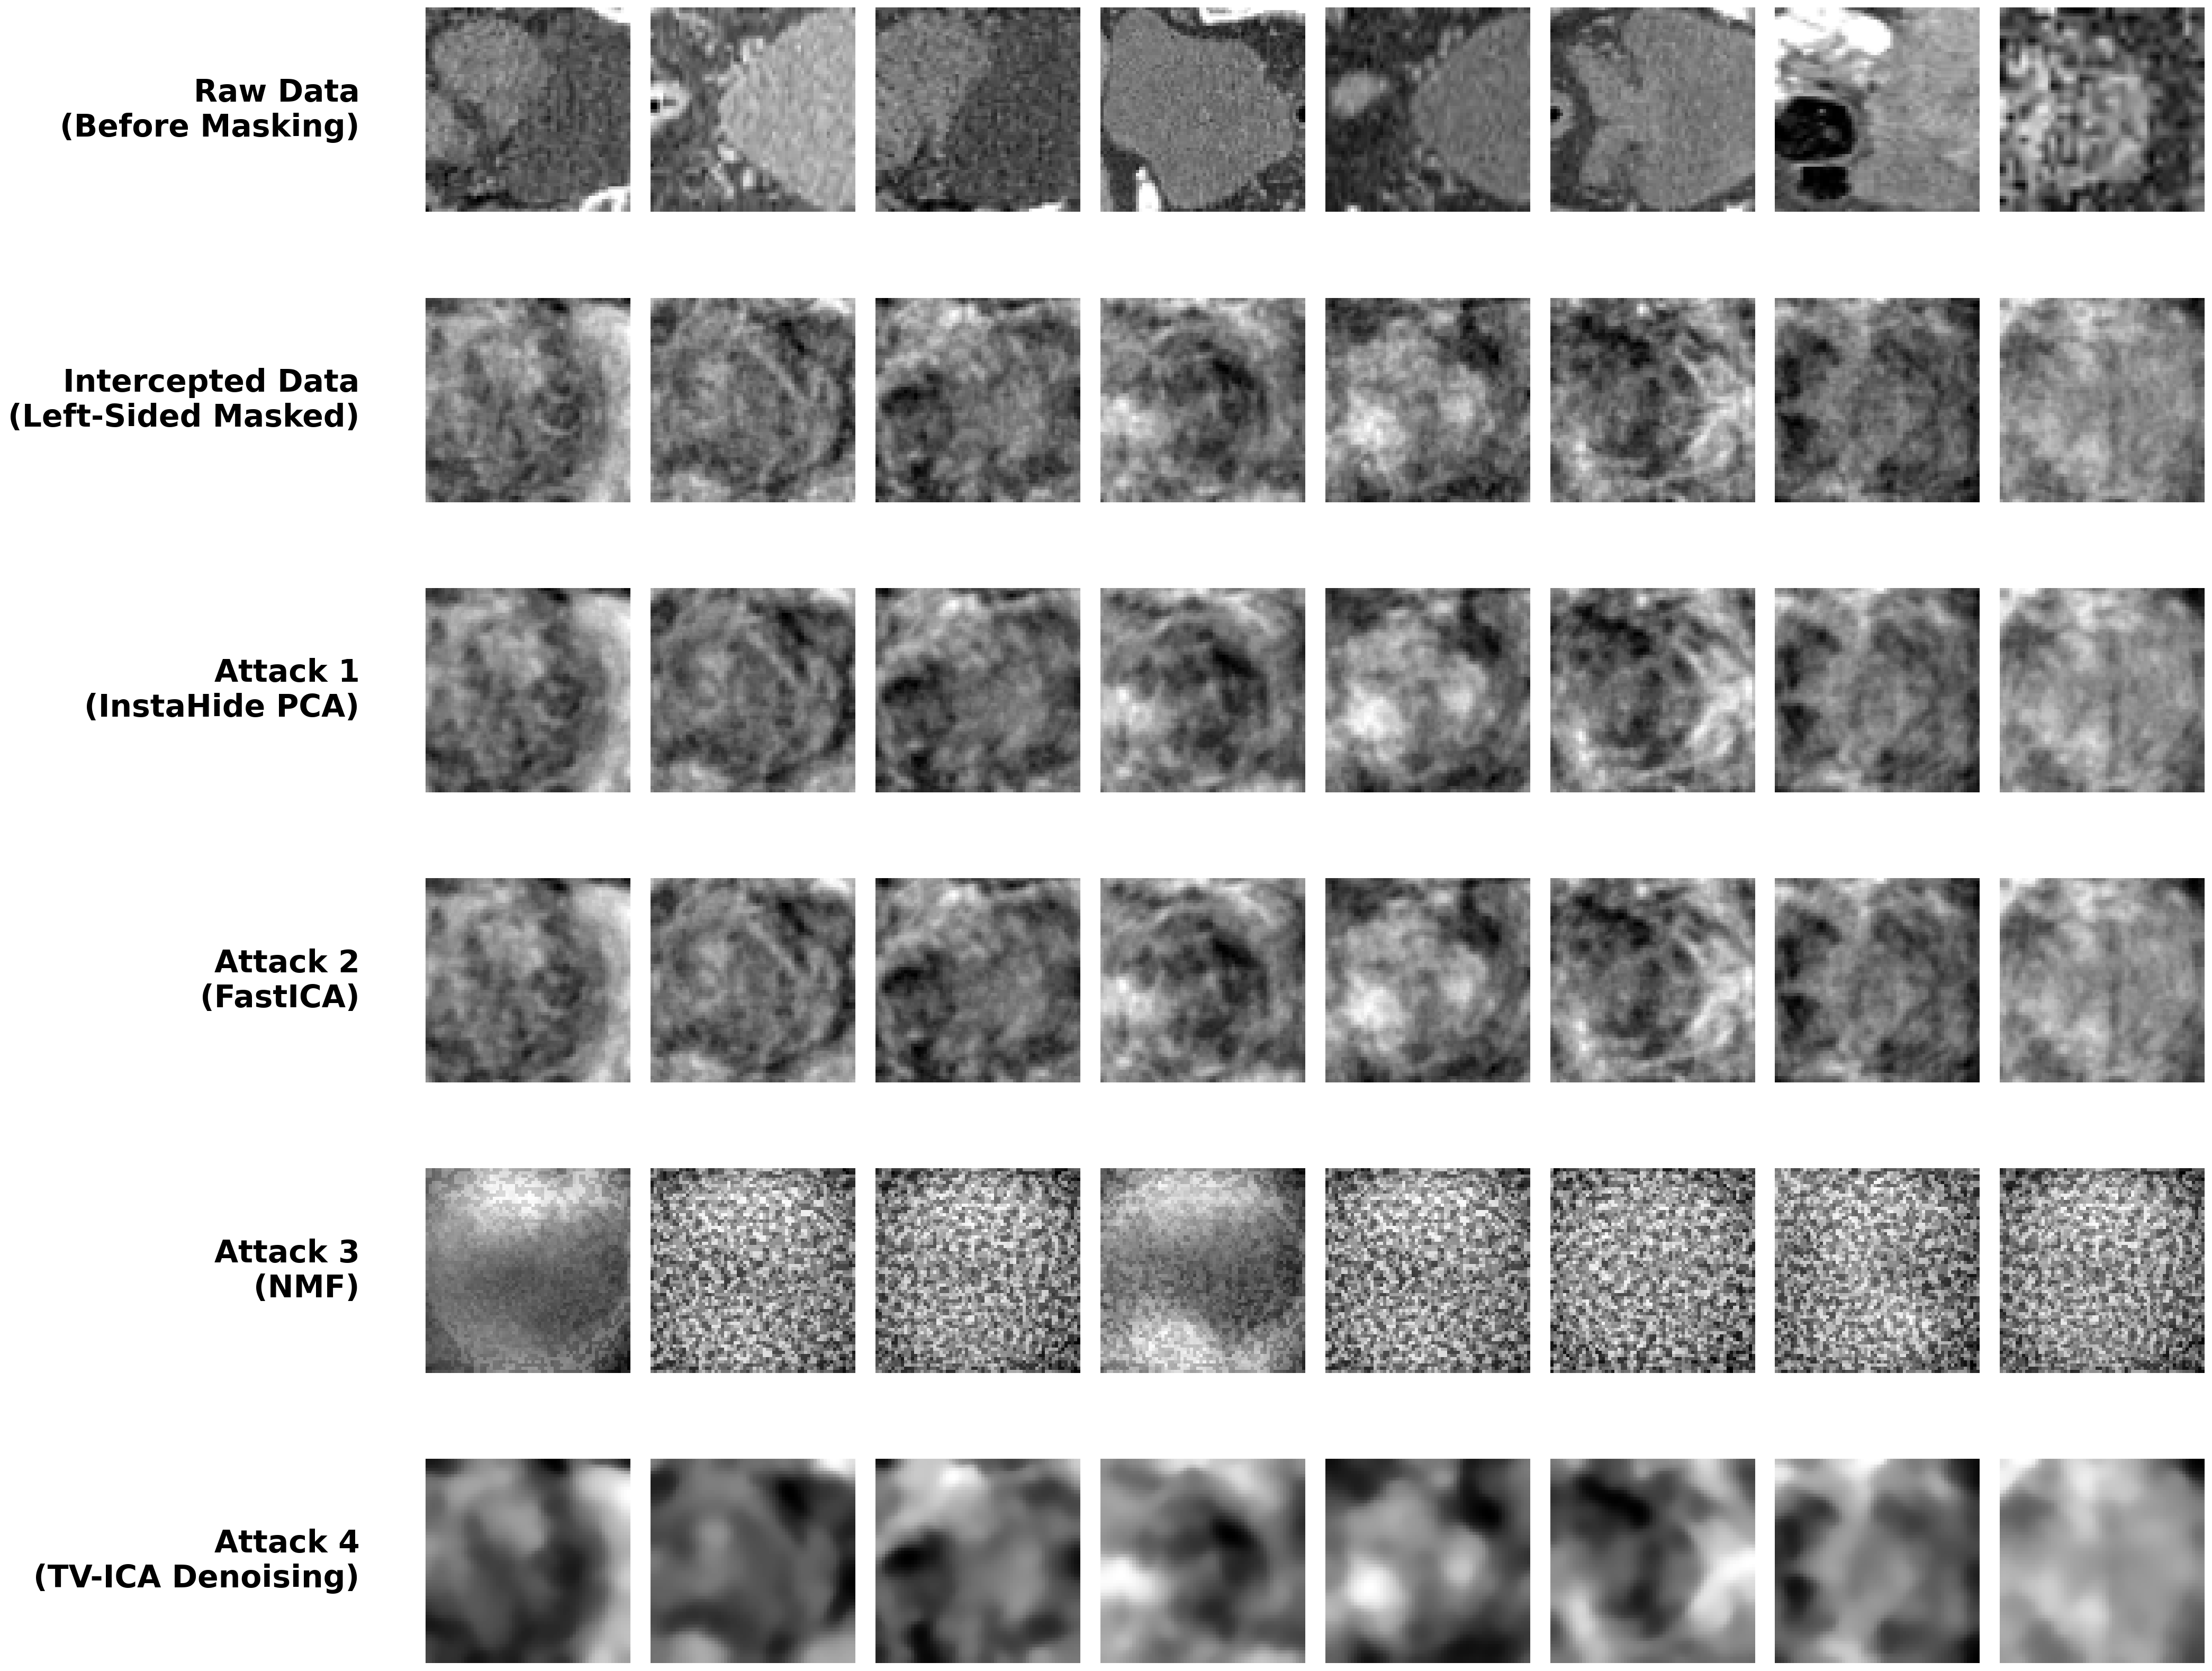

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.decomposition import PCA, FastICA, NMF
from skimage.restoration import denoise_tv_chambolle
import warnings
warnings.filterwarnings('ignore') # Ignore convergence warnings for clean output

# ==========================================
# 0. FETCH 2000 RAW IMAGES & SIMULATE INTERCEPTION
# ==========================================
# Pull exactly one batch from raw_loader
data_iterator = iter(raw_loader)
raw_images, labels = next(data_iterator)

# raw_images is flattened by your dataloader: shape (B, H*W)
B, flat_dim = raw_images.shape
H = int(np.sqrt(flat_dim)) # Automatically calculates 64
W = H

raw_images = raw_images.to(device)
labels = labels.to(device).squeeze()

# To perfectly align Raw Data with Masked Data, we apply your exact masking logic
X_masked_list = []
raw_aligned_list = []

unique_classes = torch.unique(labels)
for cls in unique_classes:
    indices = (labels == cls).nonzero(as_tuple=True)[0]
    X_sub = raw_images[indices]
    Y_sub = labels[indices]
    n_c = len(indices)

    if n_c > 1:
        # Using your notebook's exact mask generator
        A_class = generate_row_mask_gpu(Y_sub, n_c, device)
        X_sub_masked = torch.matmul(A_class, X_sub) # Direct matmul on flattened vectors
    else:
        X_sub_masked = X_sub

    X_masked_list.append(X_sub_masked)
    raw_aligned_list.append(X_sub) # Keep raw images in the same newly grouped order

intercepted_data = torch.cat(X_masked_list, dim=0)
aligned_raw_images = torch.cat(raw_aligned_list, dim=0)

# ==========================================
# 1. PREPARE DATA & EXISTING ATTACKS
# ==========================================
# Move intercepted data to CPU and numpy
flattened_intercepted = intercepted_data.cpu().detach().numpy()

# NUMERICAL STABILIZATION: Normalize to prevent FastICA math from exploding
max_val = np.max(np.abs(flattened_intercepted))
if max_val > 0:
    flattened_intercepted = flattened_intercepted / max_val
flattened_intercepted = np.nan_to_num(flattened_intercepted)

# Determine max components (Cap at 512 for stability on massive batch sizes)
max_components = min(B, flat_dim, 512)

pca = PCA(n_components=max_components)
pca_features = pca.fit_transform(flattened_intercepted)
pca_reconstructed = pca.inverse_transform(pca_features)

ica = FastICA(n_components=max_components, random_state=42, max_iter=800, tol=0.05)
ica_features = ica.fit_transform(flattened_intercepted)
ica_reconstructed = ica.inverse_transform(ica_features)

# ==========================================
# 2. NEW COMPLEX ATTACKS
# ==========================================
shifted_intercepted = flattened_intercepted - np.min(flattened_intercepted)
nmf = NMF(n_components=max_components, init='nndsvda', random_state=42, max_iter=400)
nmf_features = nmf.fit_transform(shifted_intercepted)
nmf_reconstructed = nmf.inverse_transform(nmf_features)

tv_reconstructed = np.array([
    denoise_tv_chambolle(img.reshape(H, W), weight=0.15)
    for img in ica_reconstructed
])

# ==========================================
# 3. MASSIVE VISUALIZATION
# ==========================================
num_samples = 8
num_rows = 6

# High DPI and massive figsize for maximum clarity
fig, axes = plt.subplots(num_rows, num_samples, figsize=(32, 24), dpi=150)

row_titles = [
    "Raw Data\n(Before Masking)",
    "Intercepted Data\n(Left-Sided Masked)",
    "Attack 1\n(InstaHide PCA)",
    "Attack 2\n(FastICA)",
    "Attack 3\n(NMF)",
    "Attack 4\n(TV-ICA Denoising)"
]

for j in range(num_samples):
    axes[0, j].imshow(aligned_raw_images[j].cpu().numpy().reshape(H, W), cmap='gray')
    axes[1, j].imshow(intercepted_data[j].cpu().numpy().reshape(H, W), cmap='gray')
    axes[2, j].imshow(pca_reconstructed[j].reshape(H, W), cmap='gray')
    axes[3, j].imshow(ica_reconstructed[j].reshape(H, W), cmap='gray')
    axes[4, j].imshow(nmf_reconstructed[j].reshape(H, W), cmap='gray')
    axes[5, j].imshow(tv_reconstructed[j], cmap='gray')

for i in range(num_rows):
    for j in range(num_samples):
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        for spine in axes[i, j].spines.values():
            spine.set_visible(False)

    # Labels on the left side
    axes[i, 0].set_ylabel(row_titles[i], fontsize=28, fontweight='bold',
                          rotation=0, ha='right', va='center', labelpad=60)

# Adjust spacing so the massive images don't overlap with the titles
plt.subplots_adjust(left=0.25, right=0.95, top=0.95, bottom=0.05, wspace=0.1, hspace=0.1)
plt.show()